In [ ]:
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/dsp/audio/period.wav

In [426]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dst, idst
from scipy.interpolate import interp1d
from scipy.io import wavfile

In [427]:
fs, data = wavfile.read(r"period.wav")

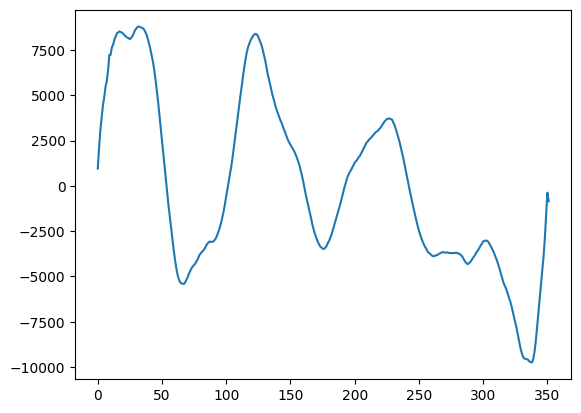

In [428]:
plt.plot(data)

In [429]:
multipl_period = list(data) * 10

In [430]:
def sine_transform(signal):
    """
    Используем дискретное синус-преобразование (DST) типа II
    """
    return dst(signal, type=2, norm='ortho')

In [431]:
def inverse_sine_transform(spectrum, n_points):
    """
    Обратное дискретное синус-преобразование (DST) типа II
    """
    return idst(spectrum, type=2, norm='ortho', n=n_points)

In [432]:
sp_period = sine_transform(data)
sp_mult_period = sine_transform(multipl_period)

In [433]:
frequencies_period = np.fft.rfftfreq(len(data), 1/fs)
amplitudes_period = sp_period[:len(frequencies_period)]

frequencies_mult_period = np.fft.rfftfreq(len(multipl_period), 1/fs)
amplitudes_mult_period = sp_mult_period[:len(frequencies_mult_period)]

mask_period = frequencies_period <= 8000
mask_mult_period = frequencies_mult_period <= 8000

Text(0.5, 1.0, 'Спектр разложения размноженного периода')

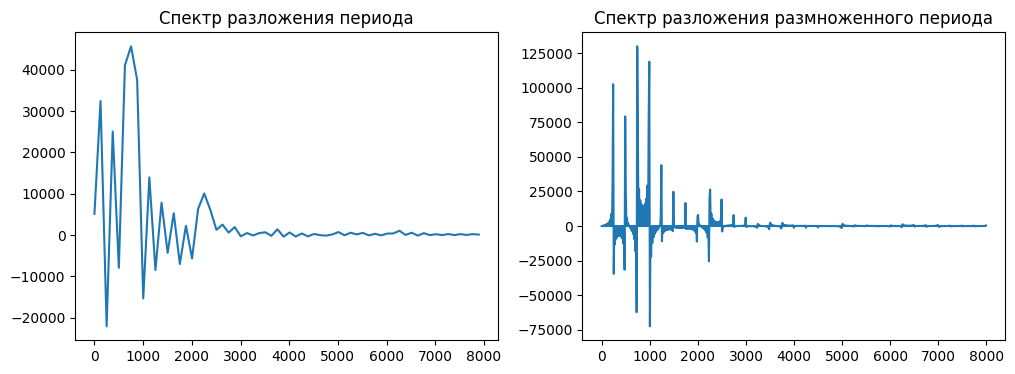

In [434]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(frequencies_period[mask_period], amplitudes_period[mask_period])
plt.title('Спектр разложения периода')

plt.subplot(1, 2, 2)
plt.plot(frequencies_mult_period[mask_mult_period], amplitudes_mult_period[mask_mult_period])
plt.title('Спектр разложения размноженного периода')

In [435]:
def interpolate_spectrum(frequencies, amplitudes, f_max, step=10.0):
    """
    Интерполяция спектра на равномерную сетку частот.
    """
    new_frequencies = np.arange(0, f_max + step, step)
    interpolator = interp1d(frequencies, amplitudes, kind='linear',
                            fill_value=0.0, bounds_error=False)
    new_amplitudes = interpolator(new_frequencies)
    return new_frequencies, new_amplitudes

In [436]:
frequencies_period_interp, amplitudes_period_interp = interpolate_spectrum(frequencies_period, amplitudes_period, 8000)
frequencies_mult_period_interp, amplitudes_mult_period_interp = interpolate_spectrum(frequencies_mult_period, amplitudes_mult_period, 8000)

In [437]:
len(frequencies_mult_period), len(frequencies_mult_period_interp)

(1761, 801)

In [438]:
len(frequencies_period), len(frequencies_period_interp)

(177, 801)

Text(0.5, 1.0, 'Спектр разложения размноженного периода интерполированный')

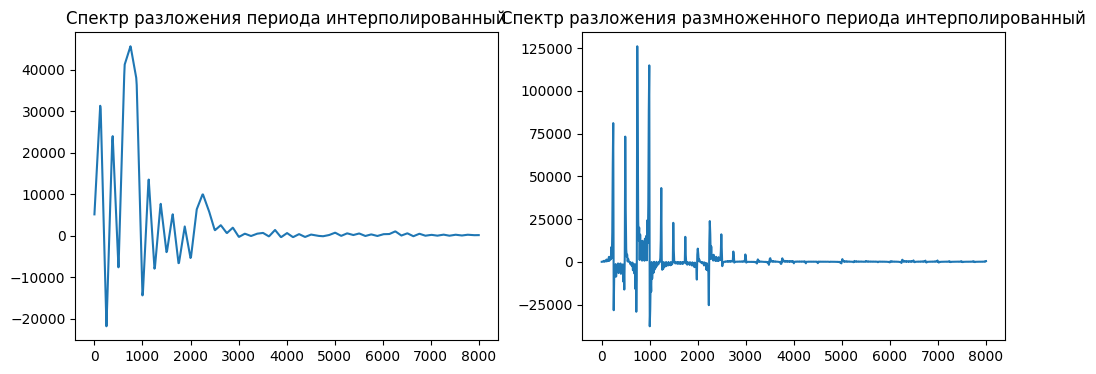

In [439]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(frequencies_period_interp, amplitudes_period_interp)
plt.title('Спектр разложения периода интерполированный')

plt.subplot(1, 2, 2)
plt.plot(frequencies_mult_period_interp, amplitudes_mult_period_interp)
plt.title('Спектр разложения размноженного периода интерполированный')

Дальше работаем только с неинтерполированным спектром размноженного периода


In [440]:
def find_peaks(amplitudes, frequencies, min_height_ratio=0.01):
    """
    Находим локальные максимумы в спектре.
    """
    peaks = []
    max_amplitude = np.max(amplitudes)
    min_height = max_amplitude * min_height_ratio

    print(max_amplitude, min_height)

    for i in range(1, len(amplitudes) - 1):
        if amplitudes[i] > amplitudes[i-1] and amplitudes[i] > amplitudes[i+1]:
            if amplitudes[i] >= min_height:
                peaks.append((frequencies[i], amplitudes[i]))

    return peaks

In [441]:
peaks = find_peaks(amplitudes_mult_period, frequencies_mult_period)
len(peaks)

129907.55073897849 1299.075507389785


40

In [442]:
peak_freqs = [peak[0] for peak in peaks]
peak_ampls = [peak[1] for peak in peaks]

Text(0.5, 1.0, 'Максимумы в спектре')

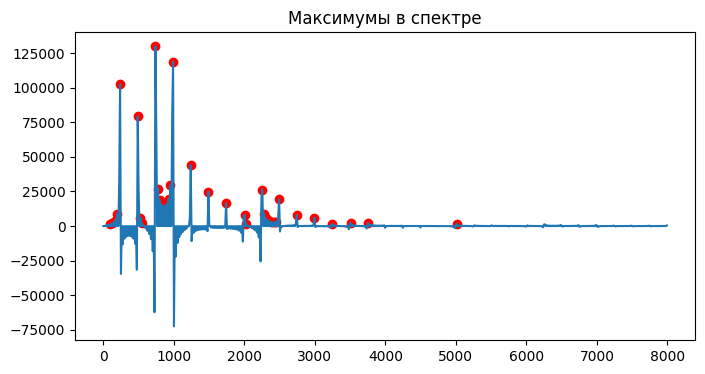

In [443]:
plt.figure(figsize=(8, 4))
plt.plot(frequencies_mult_period[mask_mult_period], amplitudes_mult_period[mask_mult_period])
plt.scatter(peak_freqs, peak_ampls, color="red")
plt.title('Максимумы в спектре')

In [444]:
def estimate_bandwidth(amplitudes, frequencies, peak_freq, peak_amp, delta=50.0):
    """
    Оцениваем ширину полосы форманты B_n по формуле (13) из статьи
    """
    # Находим индексы для частот f-delta и f+delta
    idx_center = np.argmin(np.abs(frequencies - peak_freq))
    idx_left = np.argmin(np.abs(frequencies - (peak_freq - delta)))
    idx_right = np.argmin(np.abs(frequencies - (peak_freq + delta)))

    # Амплитуды на соседних частотах
    amp_left = amplitudes[idx_left]
    amp_right = amplitudes[idx_right]

    # Вычисляем V_n по формуле (12)
    V_n = (peak_amp - (amp_left + amp_right) / 2) / (delta ** 2)

    if V_n <= 0:
        if peak_freq < 500:
            return 50.0   # Низкие форманты
        elif peak_freq < 1000:
            return 70.0   # Средние
        else:
            return 100.0   # Высокие - обычно шире

    # Ширина полосы по формуле (13)
    bandwidth = np.sqrt(peak_amp / V_n)

    return bandwidth

In [445]:
def calculate_formant_energy(amplitude, bandwidth):
    """
    Вычисляем энергию форманты по формуле (14)
    """
    energy = (np.pi / 2) * (amplitude ** 2) * bandwidth

    # Относительный уровень в дБ
    if energy > 0:
        level_db = 10 * np.log10(energy)
    else:
        level_db = -100.0

    return energy, level_db

In [446]:
formants = []
total_energy = 0.0

temp_formants = []
for peak_freq, peak_amp in peaks:
    bandwidth = estimate_bandwidth(amplitudes_mult_period, frequencies_mult_period, peak_freq, peak_amp, delta=50)
    energy, level_db = calculate_formant_energy(peak_amp, bandwidth)
    temp_formants.append({
            'frequency': peak_freq,
            'amplitude': peak_amp,
            'bandwidth': bandwidth,
            'energy': energy,
            'level_db': level_db
    })
    total_energy += energy

In [447]:
# Фильтруем форманты по относительной энергии (игнорируем <1% от суммы)
min_energy_ratio=0.01

if total_energy > 0:
    for f in temp_formants:
        rel_energy = f['energy'] / total_energy
        if rel_energy >= min_energy_ratio:
            formants.append(f)

In [448]:
len(temp_formants), len(formants)

(40, 8)

Text(0.5, 1.0, 'Центры и ширины формант')

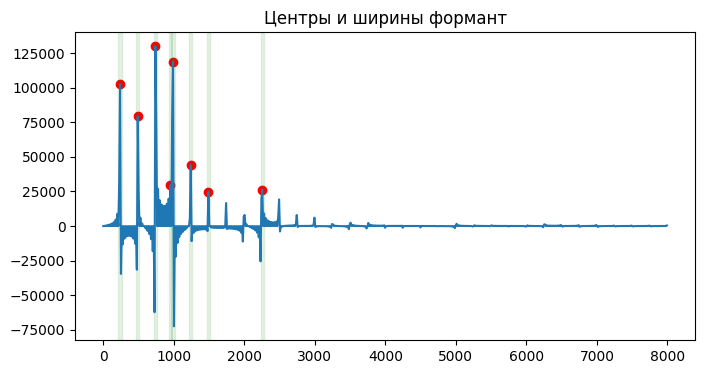

In [449]:
formants_freqs = [peak["frequency"] for peak in formants]
formants_ampls = [peak["amplitude"] for peak in formants]

plt.figure(figsize=(8, 4))
plt.plot(frequencies_mult_period[mask_mult_period], amplitudes_mult_period[mask_mult_period])
plt.scatter(formants_freqs, formants_ampls, color="red")
for formant in formants:
    bw = formant["bandwidth"]
    center_freq = formant["frequency"]
    plt.axvspan(center_freq-bandwidth/2, center_freq+bandwidth/2, color='green', alpha=0.1)

plt.title('Центры и ширины формант')

In [450]:
for formant in formants:
  print(formant["frequency"], formant["bandwidth"])

238.03977272727275 50.0
488.60795454545456 50.0
739.1761363636364 50.0
952.159090909091 35.72856521054583
989.7443181818182 50.0
1240.3125 50.0
1490.880681818182 50.0
2255.1136363636365 48.852732488767465


In [451]:
def check_formant_overlap(formant1, formant2):
    """
    Проверяем, перекрываются ли две форманты
    """
    left1 = formant1['frequency'] - formant1['bandwidth'] / 2
    right1 = formant1['frequency'] + formant1['bandwidth'] / 2
    left2 = formant2['frequency'] - formant2['bandwidth'] / 2
    right2 = formant2['frequency'] + formant2['bandwidth'] / 2

    # Перекрытие есть, если интервалы пересекаются
    return not (right1 < left2 or right2 < left1)

In [452]:
def group_overlapping_formants(formants):
    """
    Группируем перекрывающиеся форманты в кластеры
    """
    n = len(formants)
    visited = [False] * n
    clusters = []

    for i in range(n):
        if not visited[i]:
            cluster = [i]
            visited[i] = True

            changed = True
            while changed:
                changed = False
                for j in range(n):
                    if not visited[j]:
                        for k in cluster:
                            if check_formant_overlap(formants[k], formants[j]):
                                cluster.append(j)
                                visited[j] = True
                                changed = True
                                break
                    if changed:
                        break

            clusters.append(cluster)

    return clusters

In [453]:
def merge_formants_cluster(formants, cluster_indices):
    """
    Объединяем кластер перекрывающихся формант в одну
    """
    cluster_formants = [formants[i] for i in cluster_indices]

    # Находим форманту с максимальной амплитудой (центр)
    dominant = max(cluster_formants, key=lambda x: x['amplitude'])
    center_freq = dominant['frequency']

    # Находим левую границу: freq - bandwidth/2 у самой левой форманты
    leftmost = min(cluster_formants, key=lambda x: x['frequency'] - x['bandwidth'] / 2)
    left_boundary = leftmost['frequency'] - leftmost['bandwidth'] / 2

    # Находим правую границу: freq + bandwidth/2 у самой правой форманты
    rightmost = max(cluster_formants, key=lambda x: x['frequency'] + x['bandwidth'] / 2)
    right_boundary = rightmost['frequency'] + rightmost['bandwidth'] / 2

    # Ширина = от левой до правой границы
    merged_bandwidth = right_boundary - left_boundary

    # Суммарная амплитуда
    merged_amplitude = sum(f['amplitude'] for f in cluster_formants)

    # Суммарная энергия
    merged_energy = (np.pi / 2) * merged_amplitude**2 * merged_bandwidth
    merged_level_db = 10 * np.log10(merged_energy + 1e-10)

    return {
        'frequency': center_freq,
        'amplitude': merged_amplitude,
        'bandwidth': merged_bandwidth,
        'energy': merged_energy,
        'level_db': merged_level_db,
        'merged_from': len(cluster_formants)
    }

In [454]:
def resolve_dependent_formants(formants):
    """
    находим и объединяем перекрывающиеся форманты
    """
    # Сортируем по частоте
    formants_sorted = sorted(formants, key=lambda x: x['frequency'])

    # Группируем перекрывающиеся
    clusters = group_overlapping_formants(formants_sorted)

    # Объединяем каждый кластер
    independent_formants = []
    for cluster in clusters:
        if len(cluster) == 1:
            # Одиночная форманта, не перекрывается
            independent_formants.append(formants_sorted[cluster[0]])
        else:
            # Несколько перекрывающихся - объединяем
            merged = merge_formants_cluster(formants_sorted, cluster)
            independent_formants.append(merged)

    # Сортируем результат по частоте
    independent_formants.sort(key=lambda x: x['frequency'])

    return independent_formants

In [455]:
resolved = resolve_dependent_formants(formants)
len(resolved)

7

Text(0.5, 1.0, 'Центры и ширины формант')

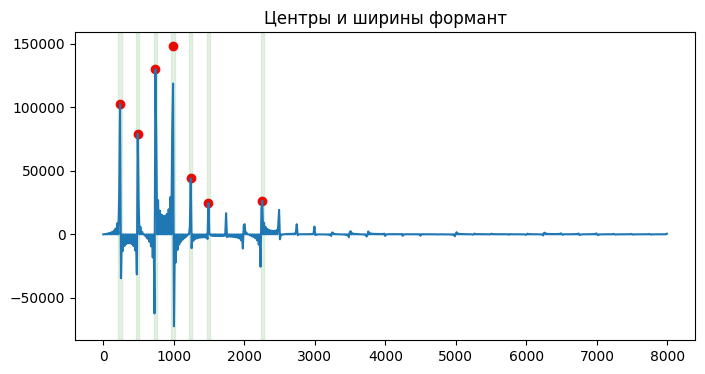

In [456]:
formants_freqs = [peak["frequency"] for peak in resolved]
formants_ampls = [peak["amplitude"] for peak in resolved]

plt.figure(figsize=(8, 4))
plt.plot(frequencies_mult_period[mask_mult_period], amplitudes_mult_period[mask_mult_period])
plt.scatter(formants_freqs, formants_ampls, color="red")
for formant in resolved:
    bw = formant["bandwidth"]
    center_freq = formant["frequency"]
    plt.axvspan(center_freq-bandwidth/2, center_freq+bandwidth/2, color='green', alpha=0.1)

plt.title('Центры и ширины формант')

Задание. Ресинтезируйте период сигнала обратно по формуле 15.

 C_n = 2 * np.pi * B_n * A_n, где B_n и A_n - ширина и амплитуда формант